
Import Libraries



In [1]:
# =========================
# 1) Import Libraries
# =========================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, random_split

Data Preprocessing

In [2]:
# =========================
# 2) Data Preprocessing
# =========================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST Dataset
full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

# Split Train & Validation
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 346kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


Build MLP Model

In [3]:
# =========================
# 3) Build MLP Model
# =========================

class MLP(nn.Module):

    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(

            # Input Layer → Hidden Layer 1
            nn.Linear(28 * 28, 128),

            nn.ReLU(),

            nn.Dropout(0.2),

            # Hidden Layer 1 → Hidden Layer 2
            nn.Linear(128, 64),

            nn.ReLU(),

            # Output Layer
            nn.Linear(64, 10)
        )

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        return self.model(x)

In [4]:
# =========================
# 4) Initialize Model
# =========================

model = MLP()

print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


Loss Function & Optimizer

In [5]:
# =========================
# 5) Loss Function & Optimizer
# =========================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Training &  VALIDATION

In [6]:
# =========================
# 6) Training Loop
# =========================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

epochs = 10

for epoch in range(epochs):

    # ================= TRAIN =================

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Forward
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    train_accuracies.append(train_acc)

    # ================= VALIDATION =================

    model.eval()

    val_running_loss = 0

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)

    val_acc = 100 * val_correct / val_total

    val_losses.append(val_loss)

    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

Epoch [1/10]
Train Loss: 0.4736
Train Accuracy: 85.56%
Validation Loss: 0.2484
Validation Accuracy: 92.33%
Epoch [2/10]
Train Loss: 0.2367
Train Accuracy: 92.85%
Validation Loss: 0.1766
Validation Accuracy: 94.46%
Epoch [3/10]
Train Loss: 0.1877
Train Accuracy: 94.20%
Validation Loss: 0.1384
Validation Accuracy: 95.86%
Epoch [4/10]
Train Loss: 0.1648
Train Accuracy: 94.83%
Validation Loss: 0.1717
Validation Accuracy: 94.58%
Epoch [5/10]
Train Loss: 0.1491
Train Accuracy: 95.45%
Validation Loss: 0.1182
Validation Accuracy: 96.47%
Epoch [6/10]
Train Loss: 0.1351
Train Accuracy: 95.74%
Validation Loss: 0.1247
Validation Accuracy: 96.38%
Epoch [7/10]
Train Loss: 0.1258
Train Accuracy: 96.01%
Validation Loss: 0.1072
Validation Accuracy: 96.76%
Epoch [8/10]
Train Loss: 0.1189
Train Accuracy: 96.16%
Validation Loss: 0.1147
Validation Accuracy: 96.68%
Epoch [9/10]
Train Loss: 0.1113
Train Accuracy: 96.40%
Validation Loss: 0.1056
Validation Accuracy: 97.08%
Epoch [10/10]
Train Loss: 0.1101
Trai

In [7]:
# =========================
# 7) Test Evaluation
# =========================

model.eval()

test_correct = 0
test_total = 0

test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (predicted == labels).sum().item()

final_test_accuracy = 100 * test_correct / test_total

final_test_loss = test_loss / len(test_loader)

print("\n===== Final Results =====")

print(f"Test Accuracy: {final_test_accuracy:.2f}%")

print(f"Final Test Loss: {final_test_loss:.4f}")


===== Final Results =====
Test Accuracy: 97.11%
Final Test Loss: 0.0991


Visualization

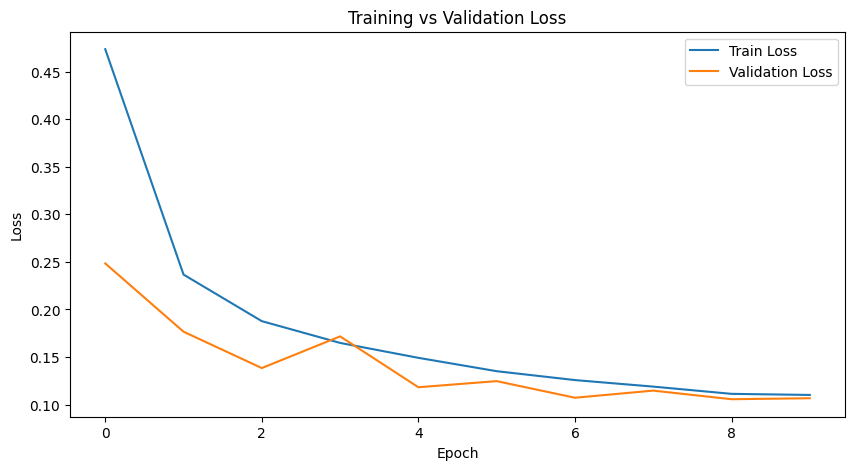

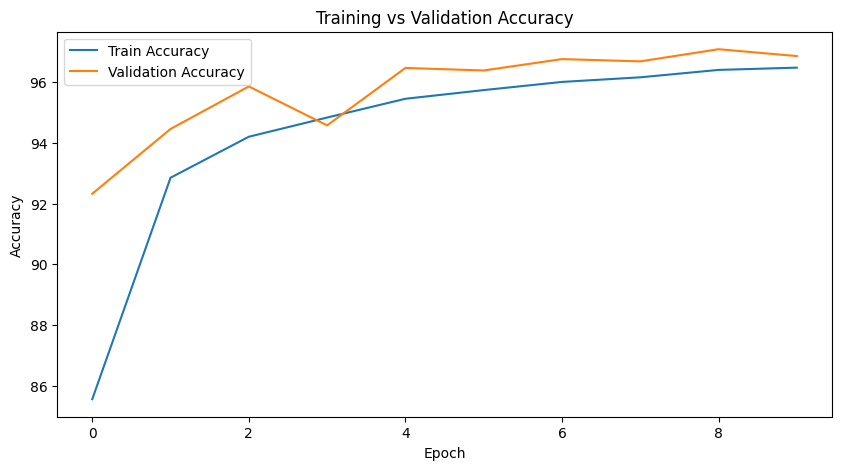

In [8]:
# =========================
# 8) Visualization
# =========================

# Loss Curves
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()


# Accuracy Curves
plt.figure(figsize=(10,5))

plt.plot(train_accuracies, label='Train Accuracy')

plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

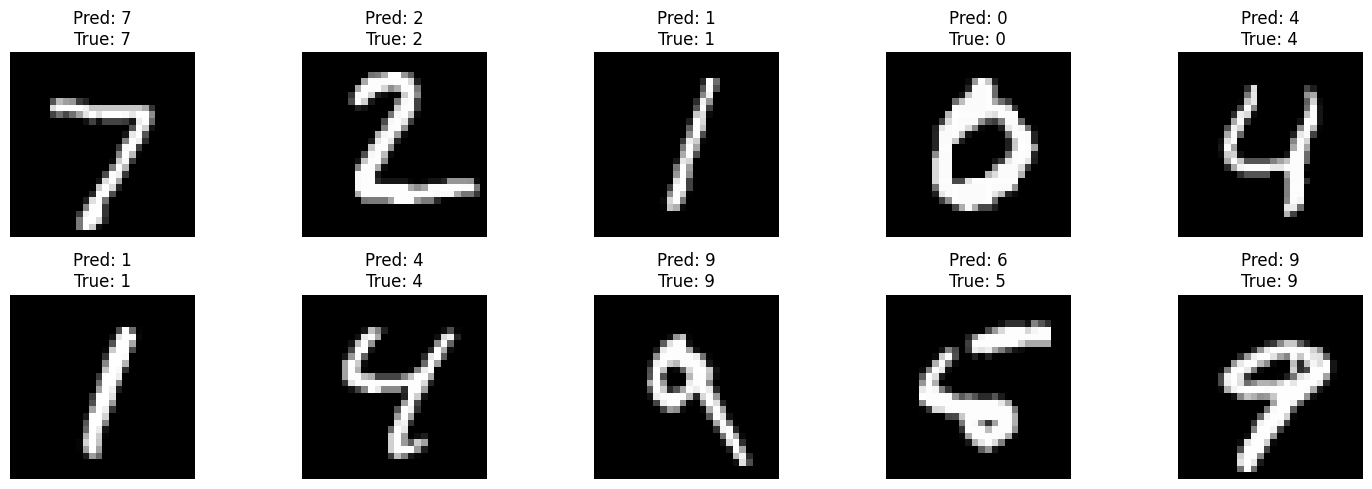

In [10]:
# =========================
# Show Predictions
# =========================

model.eval()

examples = iter(test_loader)

images, labels = next(examples)

outputs = model(images)

_, predictions = torch.max(outputs, 1)

# Display first 10 images
plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2, 5, i+1)

    # Convert image shape
    image = images[i].squeeze()

    plt.imshow(image, cmap='gray')

    plt.title(
        f"Pred: {predictions[i].item()}\nTrue: {labels[i].item()}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()